In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris


In [2]:
iris = load_iris()
X= iris.data[:,:2]
df = pd.DataFrame(X,columns = ['sepal length','sepal width'])


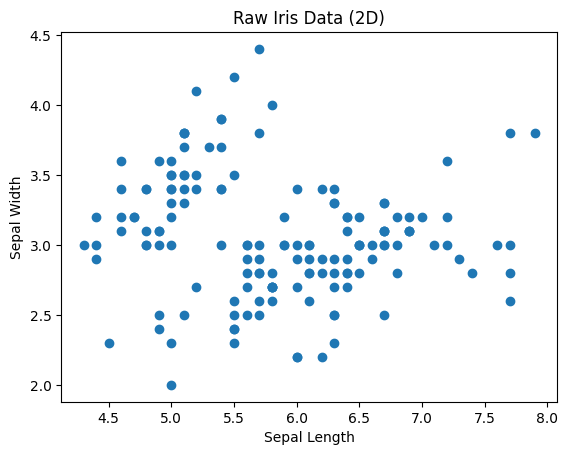

In [6]:
plt.scatter(df['sepal length'], df['sepal width'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Raw Iris Data (2D)')
plt.show()

Text(0.5, 1.0, 'Elbow Method')

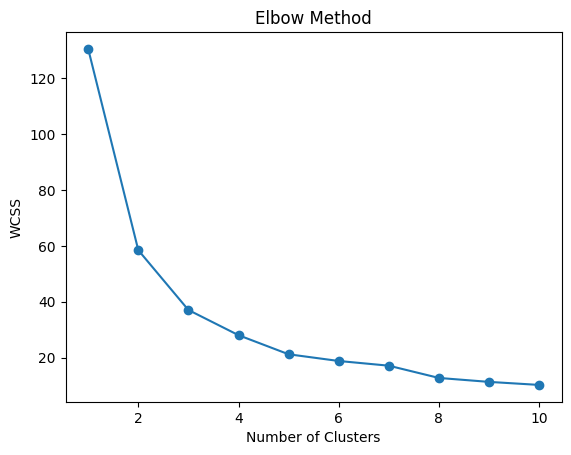

In [7]:
#Now using Elbow Method
wcss = [] #metric used here within sum of sq. distance motives to reduces as possible
for i in range(1,11):
  km= KMeans(n_clusters=i,random_state=99)
  km.fit(X)
  wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')


In [8]:
#choose 3
km = KMeans(n_clusters= 3,random_state = 42)
y_means = km.fit_predict(X)

In [9]:
y_means

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

Text(0.5, 1.0, 'K-Means Clustering (K=3)')

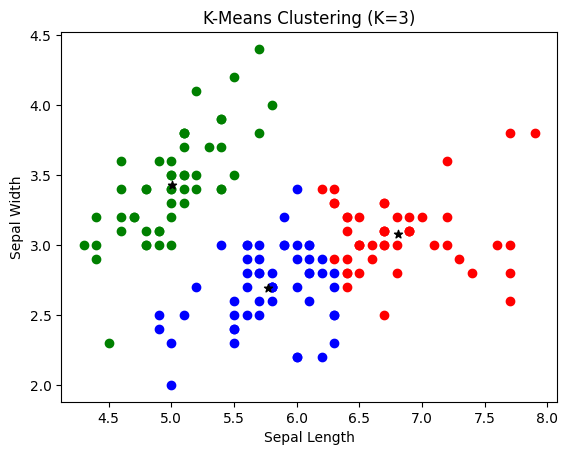

In [10]:
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], color='red', label='Cluster 1')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], color='blue', label='Cluster 2')
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], color='green', label='Cluster 3')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='black', marker='*', label='Centroids')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering (K=3)')

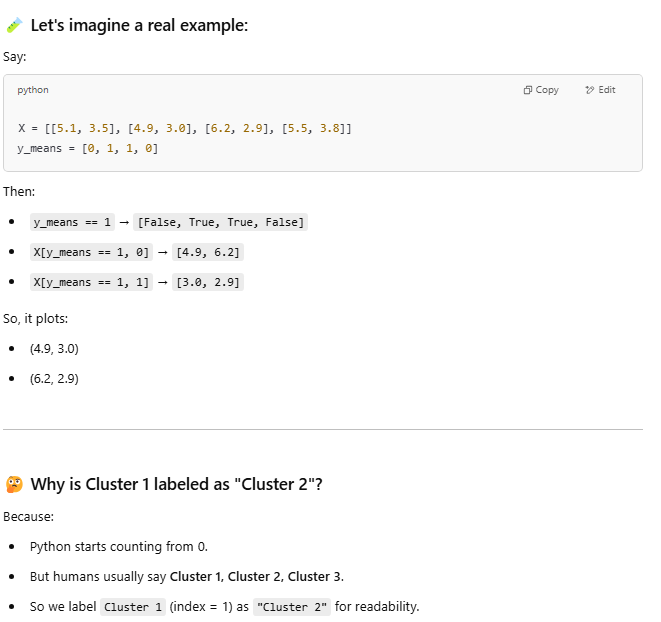

##2. K-Means Clustering on 3D Data (Synthetic Blobs)


In [11]:
from sklearn.datasets import make_blobs
import plotly.express as px

X,_ = make_blobs(n_samples = 200,centers = 4,n_features = 3,random_state = 42)

fig = px.scatter_3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], title='Raw 3D Data')
fig.show()

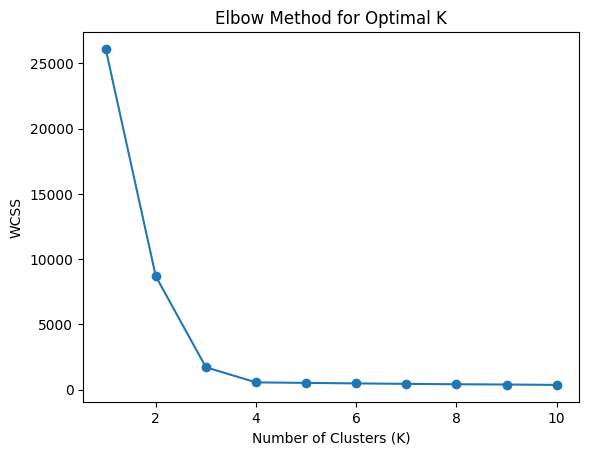

In [12]:
# Elbow Method
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

# Apply K-Means with K=4 (since we generated 4 centers)
km = KMeans(n_clusters=4, random_state=42)
y_pred = km.fit_predict(X)



In [13]:
df = pd.DataFrame(X, columns=['x', 'y', 'z'])
df['cluster'] = y_pred
fig = px.scatter_3d(df, x='x', y='y', z='z', color='cluster', title='K-Means Clustering (K=4)')
fig.show()

In [14]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y_pred)

In [15]:
score

np.float64(0.7776120220092421)

Here are some **interview questions and answers** based on the K-Means clustering concepts used in your code, along with explanations:

---

### **1. What is K-Means Clustering?**
**Answer:**  
K-Means is an **unsupervised machine learning algorithm** that partitions data into `K` clusters by minimizing the **Within-Cluster Sum of Squares (WCSS)**. It works by:
1. Randomly initializing `K` centroids.
2. Assigning each data point to the nearest centroid.
3. Updating centroids by computing the mean of assigned points.
4. Repeating until convergence (no further changes).

**Key Terms:**  
- **Centroid**: Mean position of all points in a cluster.  
- **WCSS**: Sum of squared distances between points and their centroid.  

---

### **2. How do you choose the optimal number of clusters (K)?**
**Answer:**  
The **Elbow Method** is used to determine `K`:
1. Run K-Means for different `K` values (e.g., `K=1` to `K=10`).
2. Plot **WCSS** against `K`.
3. The "elbow point" (where WCSS stops decreasing sharply) is the optimal `K`.

**Example from Code:**  
```python
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit(X)
    wcss.append(km.inertia_)  # WCSS = km.inertia_
plt.plot(range(1,11), wcss)
```

---

### **3. What is WCSS, and why is it important?**
**Answer:**  
- **WCSS (Within-Cluster Sum of Squares)** measures cluster compactness.  
- Formula:  
  \[
  \text{WCSS} = \sum_{\text{cluster } i} \sum_{\text{point } x \in \text{cluster } i} \|x - \mu_i\|^2
  \]
  where \(\mu_i\) is the centroid of cluster \(i\).  
- **Lower WCSS** = Tighter clusters.  
- Used to evaluate clustering quality and in the Elbow Method.  

---

### **4. How does K-Means handle higher-dimensional data (e.g., 3D)?**
**Answer:**  
K-Means works the same way in any dimension:
1. Computes distances (usually **Euclidean**) in `n`-dimensional space.
2. Updates centroids as the mean of points in each cluster.  
3. **Visualization** becomes challenging beyond 3D (use PCA for dimensionality reduction).

**Example from Code (3D Clustering):**  
```python
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=200, n_features=3)  # 3D data
km = KMeans(n_clusters=4)
km.fit(X)
```

---

### **5. What are the limitations of K-Means?**
**Answer:**  
- **Sensitive to initial centroids**: May converge to local optima (use `random_state` or `k-means++`).  
- **Assumes spherical clusters**: Struggles with non-convex shapes (use DBSCAN instead).  
- **Requires predefined `K`**: Elbow Method is heuristic.  
- **Outlier sensitivity**: Centroids can be skewed by outliers.  

**Mitigation:**  
- Use **K-Means++** for better initialization.  
- Scale features (e.g., `StandardScaler`).  

---

### **6. How would you visualize clusters in 3D?**
**Answer:**  
Use **Plotly** or **Matplotlib's 3D scatter plots**:
```python
import plotly.express as px
fig = px.scatter_3d(df, x='col1', y='col2', z='col3', color='label')
fig.show()
```
**Key Points:**  
- Color points by cluster labels.  
- Mark centroids with a different symbol (e.g., `*`).  

---

### **7. What is the role of `random_state` in K-Means?**
**Answer:**  
- `random_state` ensures reproducibility by fixing the random centroid initialization.  
- Without it, results may vary across runs.  

**Example:**  
```python
km = KMeans(n_clusters=3, random_state=42)  # Consistent results
```

---

### **8. How would you handle categorical data in K-Means?**
**Answer:**  
K-Means requires **numeric data**. For categorical data:
1. **Encode categories** (e.g., One-Hot Encoding).  
2. Use **K-Modes** (variant for categorical data).  
3. Apply **Gower Distance** for mixed data types.  

---

### **9. What is the time complexity of K-Means?**
**Answer:**  
- **O(n * K * I * d)**, where:  
  - `n` = Number of points.  
  - `K` = Number of clusters.  
  - `I` = Number of iterations.  
  - `d` = Number of dimensions.  
- Efficient for large datasets with few clusters (`K`).  

---

### **10. How do you evaluate clustering performance without ground truth labels?**
**Answer:**  
Use **unsupervised metrics**:  
1. **Silhouette Score**: Measures cohesion (intra-cluster) vs separation (inter-cluster).  
   - Ranges from `-1` (worst) to `1` (best).  
   ```python
   from sklearn.metrics import silhouette_score
   score = silhouette_score(X, y_pred)
   ```
2. **Davies-Bouldin Index**: Lower values = better clusters.  

---

### **Bonus: Why did you use `make_blobs` for 3D clustering?**
**Answer:**  
`make_blobs` generates **isotropic Gaussian clusters**, which are ideal for testing K-Means (since it assumes spherical clusters). It provides control over:
- Number of samples (`n_samples`).  
- Number of features (`n_features`).  
- Cluster centers (`centers`).  

---

### **Summary Table**
| Concept               | Key Points                                                                 |
|-----------------------|---------------------------------------------------------------------------|
| **K-Means**           | Unsupervised, partitions data into `K` clusters.                          |
| **Elbow Method**      | Plot WCSS vs `K`; choose the "elbow point".                               |
| **WCSS**              | Sum of squared distances to centroids; measures cluster tightness.        |
| **Centroids**         | Mean of points in a cluster; updated iteratively.                         |
| **3D Visualization**  | Use Plotly/Matplotlib 3D scatter plots.                                   |
| **Limitations**       | Sensitive to initialization, assumes spherical clusters.                  |



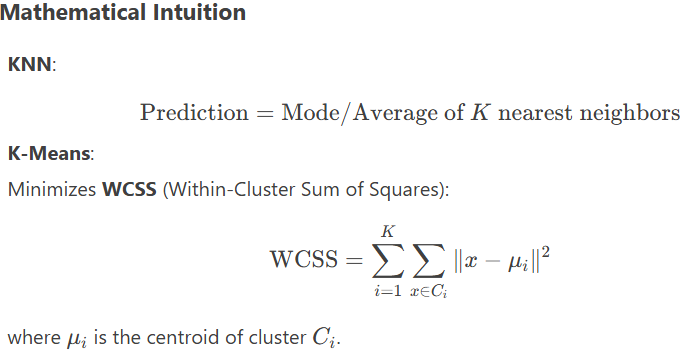

Here’s a clear comparison between **K-Nearest Neighbors (KNN)** and **K-Means** clustering, highlighting their differences in a structured format:

---

### **1. Fundamental Difference**
| **Aspect**       | **KNN (Supervised)**                          | **K-Means (Unsupervised)**                     |
|------------------|-----------------------------------------------|-----------------------------------------------|
| **Type**         | Classification/Regression algorithm           | Clustering algorithm                          |
| **Requires Labels** | Yes (needs labeled training data)          | No (works on unlabeled data)                |
| **Goal**         | Predict class/value for new data points       | Group similar data points into clusters      |

---

### **2. How They Work**
| **Aspect**       | **KNN**                                      | **K-Means**                                  |
|------------------|---------------------------------------------|---------------------------------------------|
| **Mechanism**    | - Finds `K` nearest labeled neighbors for a query point.<br>- Assigns majority class (classification) or average value (regression). | - Randomly initializes `K` centroids.<br>- Iteratively assigns points to nearest centroid and updates centroids. |
| **Key Steps**    | 1. Calculate distances (e.g., Euclidean).<br>2. Select top `K` neighbors.<br>3. Vote/average for prediction. | 1. Initialize centroids.<br>2. Assign points to clusters.<br>3. Recalculate centroids.<br>4. Repeat until convergence. |
| **Output**       | Class label or continuous value              | Cluster labels (e.g., 0, 1, 2, ...)        |

---

### **3. Key Differences**
| **Aspect**               | **KNN**                                      | **K-Means**                                  |
|--------------------------|---------------------------------------------|---------------------------------------------|
| **Data Requirement**      | Requires labeled data for training.          | Works on unlabeled data.                    |
| **Complexity**           | - Slow at prediction time (lazy learner).<br>- Stores all training data. | - Fast prediction after training.<br>- Only stores centroids. |
| **Hyperparameter `K`**   | Number of neighbors to consider.             | Number of clusters to form.                 |
| **Distance Metric**      | Critical (e.g., Euclidean, Manhattan).       | Typically Euclidean (centroid-based).       |
| **Use Case**             | - Spam detection.<br>- Medical diagnosis.    | - Customer segmentation.<br>- Image compression. |

---

### **4. Mathematical Intuition**
- **KNN**:  
  \[
  \text{Prediction} = \text{Mode/Average of } K \text{ nearest neighbors}
  \]
- **K-Means**:  
  Minimizes **WCSS** (Within-Cluster Sum of Squares):  
  \[
  \text{WCSS} = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2
  \]
  where \(\mu_i\) is the centroid of cluster \(C_i\).

---

### **5. Visualization**
- **KNN**:  
  ![KNN](https://www.researchgate.net/publication/333692283/figure/fig1/AS:769540138647553@1560443184774/Illustration-of-the-k-nearest-neighbor-algorithm-for-k-3-The-test-sample-green-circle.jpg)  
  *(Classifies the green point based on 3 nearest neighbors)*

- **K-Means**:  
  ![K-Means](https://miro.medium.com/v2/resize:fit:1400/1*KrcZK0xYgTa4qFrVtdfJhg.gif)  
  *(Iteratively partitions data into clusters)*

---

### **6. Strengths and Weaknesses**
| **Aspect**       | **KNN**                                      | **K-Means**                                  |
|------------------|---------------------------------------------|---------------------------------------------|
| **Strengths**    | - Simple to implement.<br>- No training phase (lazy learning). | - Fast for large datasets.<br>- Scalable to high dimensions. |
| **Weaknesses**   | - Slow prediction (computes distances at runtime).<br>- Sensitive to irrelevant features. | - Requires predefined `K`.<br>- Sensitive to initial centroids. |

---

### **7. Practical Example**
- **KNN**:  
  ```python
  from sklearn.neighbors import KNeighborsClassifier
  model = KNeighborsClassifier(n_neighbors=3)
  model.fit(X_train, y_train)  # Requires labels
  y_pred = model.predict(X_test)
  ```

- **K-Means**:  
  ```python
  from sklearn.cluster import KMeans
  model = KMeans(n_clusters=3)
  model.fit(X)  # No labels needed
  clusters = model.predict(X_new)
  ```

---

### **8. When to Use Which?**
- **Use KNN if**:  
  - You have labeled data.  
  - Need interpretable results (e.g., "This patient is similar to these 5 cases").  

- **Use K-Means if**:  
  - You have unlabeled data.  
  - Need to discover hidden patterns (e.g., customer segments).  

---

### **Summary**
- **KNN** = Supervised, predicts labels based on neighbors.  
- **K-Means** = Unsupervised, groups data into clusters.  



### **How to Determine `n` (Sample Size) and `k` (Number of Clusters) in K-Means Clustering**

#### **1. Understanding `n` (Sample Size)**
`n` refers to the **number of data points** in your dataset.  
- **How to find it?**  
  - In Python:  
    ```python
    import pandas as pd
    df = pd.read_csv('your_data.csv')
    n = df.shape[0]  # Number of rows = sample size
    print(f"Sample size (n) = {n}")
    ```
  - In NumPy:  
    ```python
    import numpy as np
    X = np.array([[1, 2], [3, 4], [5, 6]])
    n = X.shape[0]  # n = 3
    ```

#### **2. Determining `k` (Optimal Number of Clusters)**
Since K-Means requires `k` to be predefined, here are **4 methods** to choose it:

---

### **Method 1: Elbow Method (Most Common)**
**Idea:** Plot **WCSS (Within-Cluster Sum of Squares)** vs. `k` and pick the "elbow point."  
**Steps:**
1. Run K-Means for different `k` values (e.g., `k=1` to `k=10`).  
2. Calculate WCSS for each `k`.  
3. Plot `k` vs. WCSS and look for the "elbow" (point where WCSS stops decreasing sharply).  

**Python Code:**
```python
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # WCSS = inertia_

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()
```
**Output:**  
![Elbow Method](https://i.stack.imgur.com/5STB0.png)  
*(Choose `k=3` or `k=4` where the curve bends.)*

---

### **Method 2: Silhouette Score**
**Idea:** Measures how similar a point is to its own cluster vs. other clusters.  
- **Range:** `[-1, 1]` (Higher = Better clustering).  
- **Optimal `k`:** Maximizes the average silhouette score.  

**Python Code:**
```python
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):  # k >= 2 required
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()
```
**Output:**  
![Silhouette Score](https://i.stack.imgur.com/6JU5U.png)  
*(Pick `k` with the highest score, e.g., `k=3`.)*

---

### **Method 3: Gap Statistic**
**Idea:** Compares WCSS of your data to WCSS of random uniform data.  
- **Optimal `k`:** Largest `k` where Gap(`k`) ≥ Gap(`k+1`) - SE(`k+1`).  

**Python Code:**
```python
from gap_statistic import OptimalK  # Install: pip install gap-stat
optimal_k = OptimalK()
n_clusters = optimal_k(X, cluster_array=range(1, 11))
print(f"Optimal k = {n_clusters}")
```

---

### **Method 4: Domain Knowledge**
Sometimes, business needs dictate `k`:
- **Example:**  
  - A marketing team wants **5 customer segments** (`k=5`).  
  - An image compression algorithm uses `k=16` for 16 colors.  

---

### **Summary Table**
| **Method**          | **When to Use**                     | **Pros**                          | **Cons**                          |
|---------------------|------------------------------------|-----------------------------------|-----------------------------------|
| **Elbow Method**    | Quick visual check                 | Simple, intuitive                | Subjective (elbow point unclear)  |
| **Silhouette Score**| Precise optimal `k`                | Quantitative, robust             | Computationally heavier           |
| **Gap Statistic**   | Theoretical robustness             | Works well for complex data      | Requires extra library            |
| **Domain Knowledge**| Business-driven decisions          | Aligns with real-world needs     | May not be data-optimal           |

---

### **Final Answer**
1. **`n` (Sample Size):**  
   - Use `.shape[0]` in Pandas/NumPy.  
2. **`k` (Optimal Clusters):**  
   - **Best Practice:** Use **Elbow Method + Silhouette Score** together.  
   - **For large datasets:** Gap Statistic.  
   - **Business context:** Domain knowledge.  

